# Preprocessing & Baseline Models
**DS340 — Multiclass Genre Classification**

Baseline models: Logistic Regression, Random Forest, KNN

Evaluated on: Accuracy, Macro F1, per-class classification report

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print('Imports loaded.')

Imports loaded.


---
## 1. Load & Clean Data

In [ ]:
data = pd.read_csv('../Data/spotify-tracks-dataset.csv')
print(f'Original shape: {data.shape}')

drop_cols = ['Unnamed: 0.1', 'Unnamed: 0', 'artists', 'album_name', 'track_name']
data = data.drop(columns=[c for c in drop_cols if c in data.columns])

data = data.dropna()
data = data.drop_duplicates(subset='track_id', keep='first')
data = data.drop(columns=['track_id'])
print(f'After cleaning (unique tracks only): {data.shape}')
print(f'Genres: {data["track_genre"].nunique()}')
print(f'Rows per genre — min: {data["track_genre"].value_counts().min()}  max: {data["track_genre"].value_counts().max()}  mean: {data["track_genre"].value_counts().mean():.1f}')

In [ ]:
sampled = data.copy()
del data
gc.collect()

print(f'Data shape: {sampled.shape}')
sampled.head()

---
## 2. Encode Labels & Define Features

In [4]:
# encode genre labels
le = LabelEncoder()
sampled['genre_label'] = le.fit_transform(sampled['track_genre'])
num_classes = len(le.classes_)
print(f'Number of classes: {num_classes}')

# select audio features
feature_cols = [
    'popularity', 'duration_ms', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature'
]

X = sampled[feature_cols].copy()
X['explicit'] = X['explicit'].astype(int)
y = sampled['genre_label'].values

# free sampled df
del sampled
gc.collect()

print(f'X shape: {X.shape}, y shape: {y.shape}')

Number of classes: 114
X shape: (34200, 15), y shape: (34200,)


---
## 3. Train / Validation / Test Split + Scaling

In [5]:
# 70 / 15 / 15 split (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

del X, X_temp, y_temp
gc.collect()

print(f'Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

Train: 23,940  Val: 5,130  Test: 5,130


In [6]:
# standardize (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

print('Scaling done.')

Scaling done.


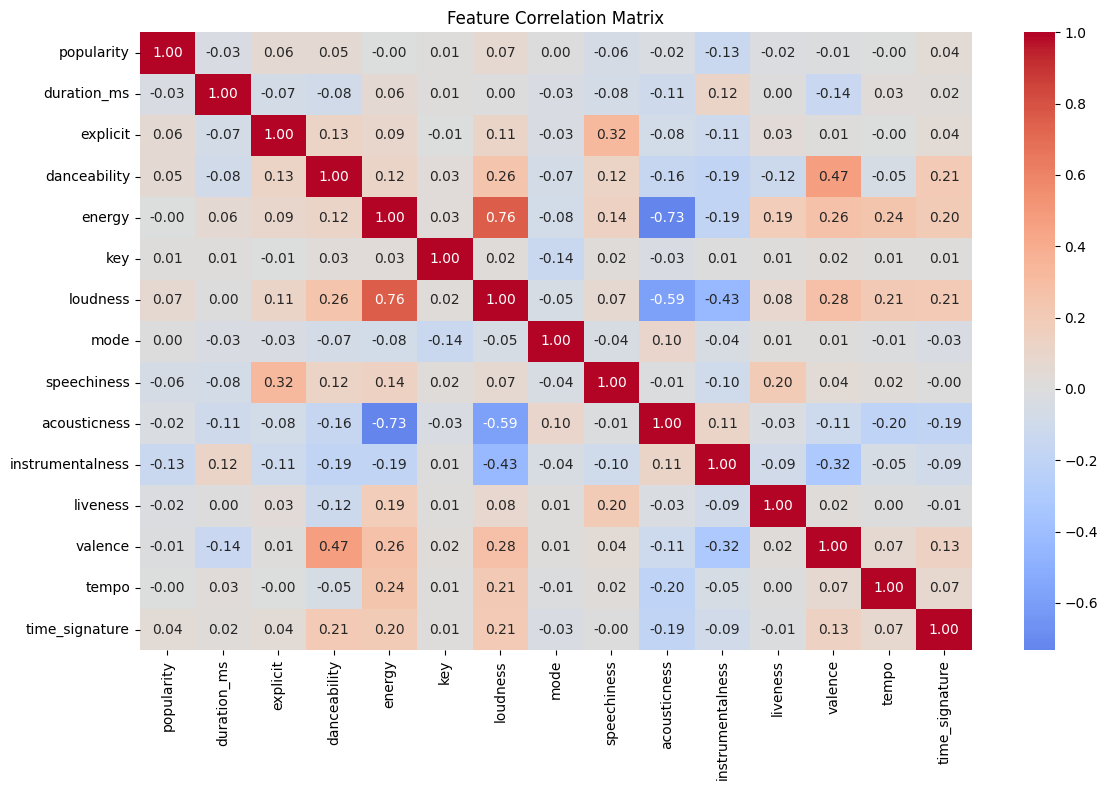

In [7]:
# feature correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    pd.DataFrame(X_train_sc, columns=feature_cols).corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

---
## 4. Baseline Models
Each model is trained, evaluated, then deleted from memory before the next one.

In [8]:
# store results
baseline_results = []

In [9]:
# Logistic Regression 
print('Training Logistic Regression')
lr = LogisticRegression(max_iter=300, solver='saga', random_state=42)
lr.fit(X_train_sc, y_train)

lr_preds = lr.predict(X_val_sc)
lr_acc = accuracy_score(y_val, lr_preds)
lr_f1 = f1_score(y_val, lr_preds, average='macro')
print(f'  Accuracy: {lr_acc:.4f}, Macro F1: {lr_f1:.4f}')

baseline_results.append({'Model': 'Logistic Regression', 'Accuracy': lr_acc, 'Macro F1': lr_f1, 'preds': lr_preds})

# free model from memory
del lr

Training Logistic Regression


  Accuracy: 0.1969, Macro F1: 0.1699


In [10]:
# Random Forest
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
rf.fit(X_train_sc, y_train)

rf_preds = rf.predict(X_val_sc)
rf_acc = accuracy_score(y_val, rf_preds)
rf_f1 = f1_score(y_val, rf_preds, average='macro')
print(f'  Accuracy: {rf_acc:.4f}, Macro F1: {rf_f1:.4f}')

baseline_results.append({'Model': 'Random Forest', 'Accuracy': rf_acc, 'Macro F1': rf_f1, 'preds': rf_preds})

del rf
gc.collect()
print('Done. Model freed from memory.')

Training Random Forest...
  Accuracy: 0.3019, Macro F1: 0.2834
Done. Model freed from memory.


In [11]:
# K-Nearest Neighbors
print('Training KNN...')
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_sc, y_train)

knn_preds = knn.predict(X_val_sc)
knn_acc = accuracy_score(y_val, knn_preds)
knn_f1 = f1_score(y_val, knn_preds, average='macro')
print(f'  Accuracy: {knn_acc:.4f}, Macro F1: {knn_f1:.4f}')

baseline_results.append({'Model': 'KNN (k=15)', 'Accuracy': knn_acc, 'Macro F1': knn_f1, 'preds': knn_preds})

del knn

Training KNN...
  Accuracy: 0.1789, Macro F1: 0.1672


In [12]:
# XGBoost (boosted trees — stronger than Random Forest baseline)
print('Training XGBoost...')
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)
xgb.fit(X_train_sc, y_train)

xgb_preds = xgb.predict(X_val_sc)
xgb_acc = accuracy_score(y_val, xgb_preds)
xgb_f1  = f1_score(y_val, xgb_preds, average='macro')
print(f'  Accuracy: {xgb_acc:.4f}, Macro F1: {xgb_f1:.4f}')

baseline_results.append({'Model': 'XGBoost', 'Accuracy': xgb_acc, 'Macro F1': xgb_f1, 'preds': xgb_preds})

del xgb
gc.collect()
print('Done. Model freed from memory.')

Training XGBoost...
  Accuracy: 0.2977, Macro F1: 0.2937
Done. Model freed from memory.


---
## 5. Compare Baselines

In [13]:
results_df = pd.DataFrame(baseline_results)[['Model', 'Accuracy', 'Macro F1']]
print('=== Baseline Comparison (Validation Set) ===')
print(results_df.to_string(index=False))

=== Baseline Comparison (Validation Set) ===
              Model  Accuracy  Macro F1
Logistic Regression  0.196881  0.169857
      Random Forest  0.301949  0.283377
         KNN (k=15)  0.178947  0.167236
            XGBoost  0.297661  0.293729


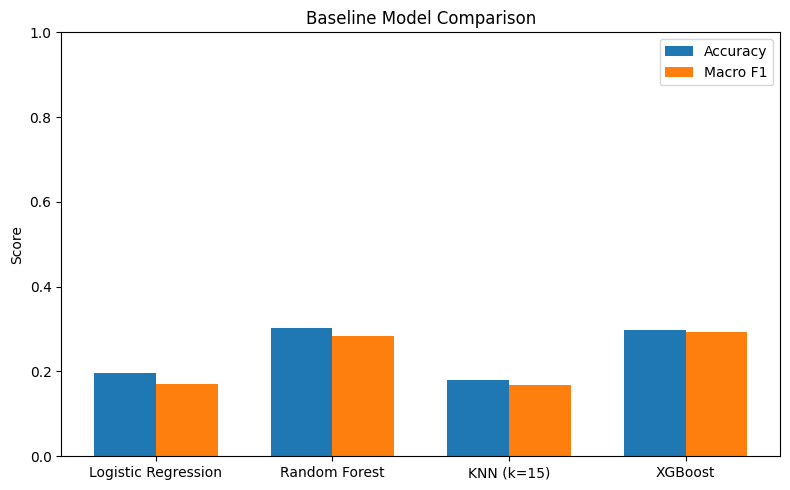

In [14]:
# bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy')
ax.bar(x + width/2, results_df['Macro F1'], width, label='Macro F1')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# classification report for best baseline
best = max(baseline_results, key=lambda r: r['Macro F1'])
print(f'Best baseline: {best["Model"]}\n')
print(classification_report(y_val, best['preds'], target_names=le.classes_))

Best baseline: XGBoost

                   precision    recall  f1-score   support

         acoustic       0.16      0.20      0.18        45
         afrobeat       0.33      0.29      0.31        45
         alt-rock       0.02      0.02      0.02        45
      alternative       0.10      0.09      0.09        45
          ambient       0.21      0.18      0.19        45
            anime       0.25      0.18      0.21        45
      black-metal       0.55      0.51      0.53        45
        bluegrass       0.40      0.38      0.39        45
            blues       0.04      0.02      0.03        45
           brazil       0.16      0.13      0.15        45
        breakbeat       0.47      0.36      0.41        45
          british       0.00      0.00      0.00        45
         cantopop       0.23      0.27      0.25        45
    chicago-house       0.44      0.36      0.40        45
         children       0.36      0.33      0.34        45
            chill       0.21   

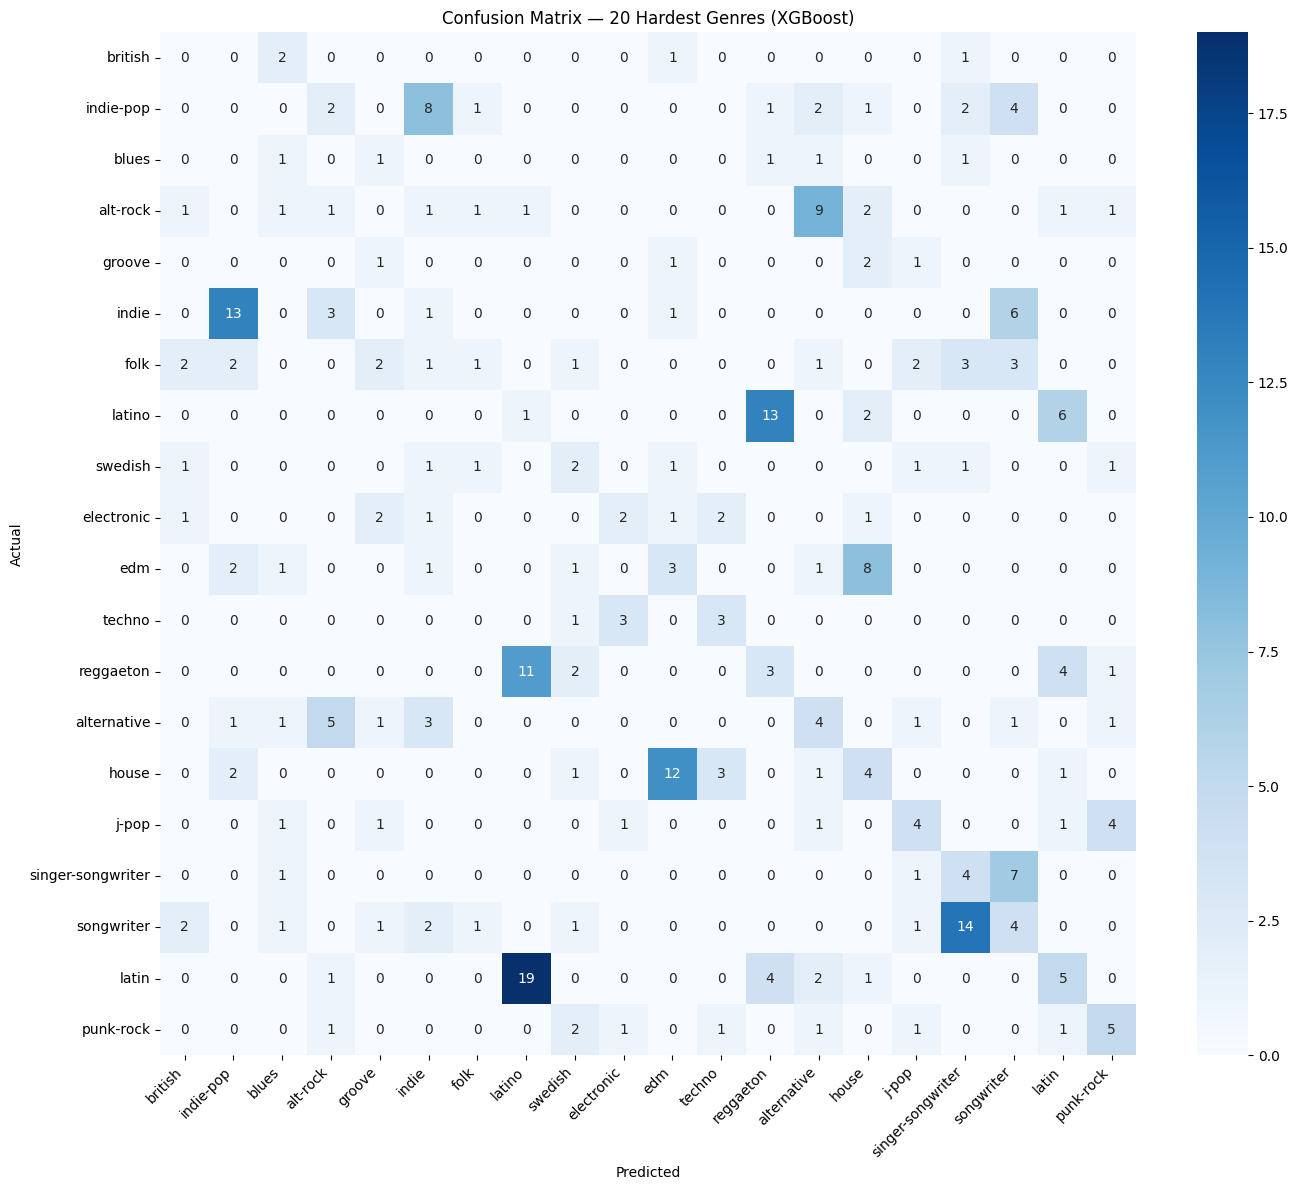


Per-class accuracy for 20 hardest genres:
  british                   0.000
  indie-pop                 0.000
  blues                     0.022
  alt-rock                  0.022
  groove                    0.022
  indie                     0.022
  folk                      0.022
  latino                    0.022
  swedish                   0.044
  electronic                0.044
  edm                       0.067
  techno                    0.067
  reggaeton                 0.067
  alternative               0.089
  house                     0.089
  j-pop                     0.089
  singer-songwriter         0.089
  songwriter                0.089
  latin                     0.111
  punk-rock                 0.111


In [16]:
# confusion matrix for best baseline (20 hardest genres)
cm = confusion_matrix(y_val, best['preds'])
per_class_acc = cm.diagonal() / cm.sum(axis=1)
worst_20 = np.argsort(per_class_acc)[:20]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm[np.ix_(worst_20, worst_20)],
    annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_[worst_20],
    yticklabels=le.classes_[worst_20]
)
plt.title(f'Confusion Matrix — 20 Hardest Genres ({best["Model"]})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nPer-class accuracy for 20 hardest genres:')
for i in worst_20:
    print(f'  {le.classes_[i]:25s} {per_class_acc[i]:.3f}')

---
## Next Steps
- Build DNN in a separate notebook
- Compare DNN results against these baselines
- Hyperparameter tuning and feature subset experiments